In [44]:
# Install required libraries
!pip install -q streamlit pyngrok joblib

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 44.7 MB/s eta 0:00:00


In [45]:
from google.colab import files

uploaded = files.upload()

Saving used_cars_data.csv to used_cars_data.csv


In [47]:
df = pd.read_csv("used_cars_data.csv")

df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [48]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Shape: (7253, 14)

Columns:
Index(['S.No.', 'Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'New_Price', 'Price'],
      dtype='object')

Missing values:
S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
New_Price            6247
Price                1234
dtype: int64

Data types:
S.No.                  int64
Name                  object
Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Mileage               object
Engine                object
Power                 object
Seats                float64
New_Price  

In [50]:
df = df.drop(columns=["S.No.", "New_Price"])

print(df.shape)

(7253, 12)


In [51]:
df = df.dropna(subset=["Price"])

print("Shape after removing missing prices:", df.shape)


Shape after removing missing prices: (6019, 12)


In [52]:
df["Mileage"] = (
    df["Mileage"]
    .astype(str)
    .str.extract(r"([\d.]+)")[0]
)

df["Mileage"] = pd.to_numeric(
    df["Mileage"],
    errors="coerce"
)


In [53]:
df["Engine"] = (
    df["Engine"]
    .astype(str)
    .str.extract(r"([\d.]+)")[0]
)

df["Engine"] = pd.to_numeric(
    df["Engine"],
    errors="coerce"
)

In [54]:
df["Power"] = (
    df["Power"]
    .astype(str)
    .str.extract(r"([\d.]+)")[0]
)

df["Power"] = pd.to_numeric(
    df["Power"],
    errors="coerce"
)

In [55]:
df.info()

print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 6019 entries, 0 to 6018
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   object 
 1   Location           6019 non-null   object 
 2   Year               6019 non-null   int64  
 3   Kilometers_Driven  6019 non-null   int64  
 4   Fuel_Type          6019 non-null   object 
 5   Transmission       6019 non-null   object 
 6   Owner_Type         6019 non-null   object 
 7   Mileage            6017 non-null   float64
 8   Engine             5983 non-null   float64
 9   Power              5876 non-null   float64
 10  Seats              5977 non-null   float64
 11  Price              6019 non-null   float64
dtypes: float64(5), int64(2), object(5)
memory usage: 611.3+ KB

Missing values:
Name                   0
Location               0
Year                   0
Kilometers_Driven      0
Fuel_Type              0
Transmission        

In [56]:
numerical_columns = [
    "Mileage",
    "Engine",
    "Power",
    "Seats"
]

for column in numerical_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )

In [57]:
categorical_columns = [
    "Location",
    "Fuel_Type",
    "Transmission",
    "Owner_Type"
]

for column in categorical_columns:
    df[column] = df[column].fillna(
        df[column].mode()[0]
    )

In [58]:
print(df.isnull().sum())

Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64


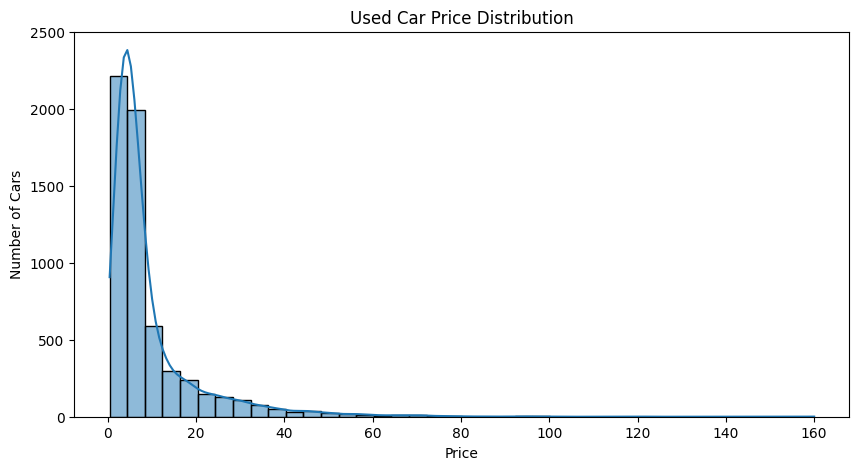

In [59]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Price"],
    bins=40,
    kde=True
)

plt.title("Used Car Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Cars")

plt.show()

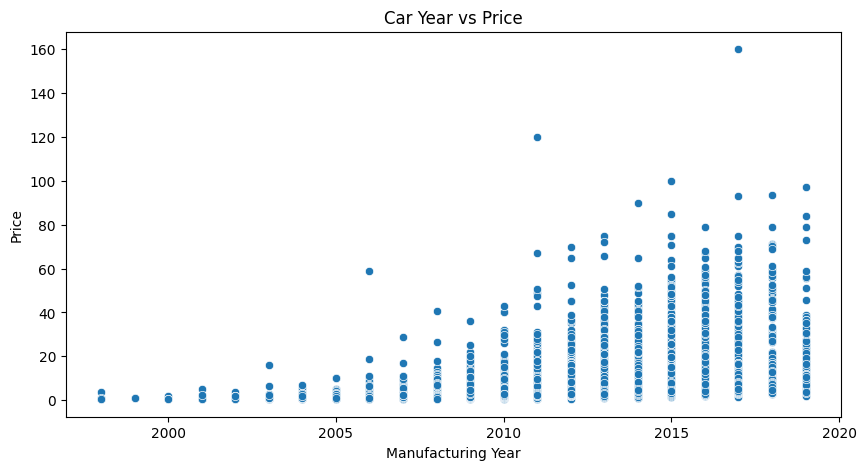

In [60]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="Year",
    y="Price"
)

plt.title("Car Year vs Price")
plt.xlabel("Manufacturing Year")
plt.ylabel("Price")

plt.show()

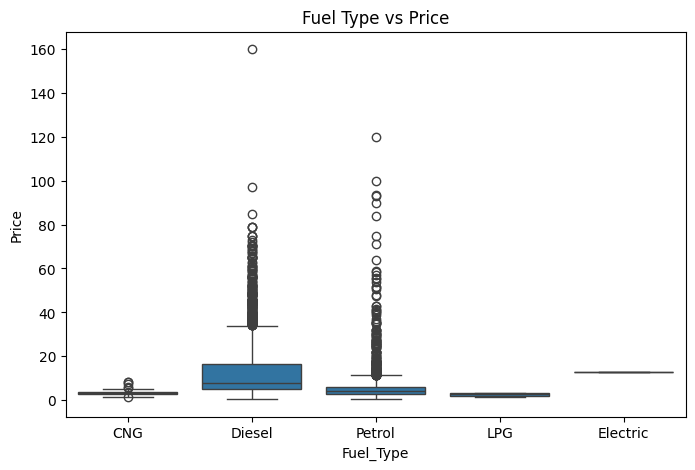

In [61]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Fuel_Type",
    y="Price"
)

plt.title("Fuel Type vs Price")

plt.show()

In [62]:
features = [
    "Name",
    "Location",
    "Year",
    "Kilometers_Driven",
    "Fuel_Type",
    "Transmission",
    "Owner_Type",
    "Mileage",
    "Engine",
    "Power",
    "Seats"
]

target = "Price"

X = df[features]
y = df[target]

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4815, 11)
Testing data: (1204, 11)


In [64]:
categorical_features = [
    "Name",
    "Location",
    "Fuel_Type",
    "Transmission",
    "Owner_Type"
]

numerical_features = [
    "Year",
    "Kilometers_Driven",
    "Mileage",
    "Engine",
    "Power",
    "Seats"
]

In [65]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [66]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [67]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [68]:
print("Training model...")

pipeline.fit(X_train, y_train)

print("Training completed!")

Training model...
Training completed!


In [69]:
y_pred = pipeline.predict(X_test)

print(y_pred[:10])

[ 5.99605 12.73235  8.0294   2.40915  2.29995  4.42295  5.13905  3.95
 13.20065  4.09035]


In [70]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("---------------------------")
print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 4))

Model Performance
---------------------------
MAE  : 1.58
RMSE : 3.94
R²   : 0.8741


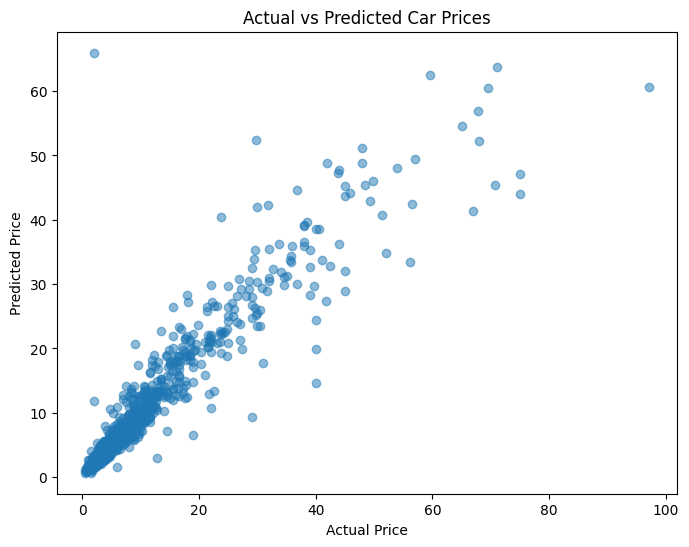

In [71]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Car Prices")

plt.show()

In [72]:
car = pd.DataFrame({
    "Name": ["Maruti Swift Dzire VDI"],
    "Location": ["Delhi"],
    "Year": [2018],
    "Kilometers_Driven": [50000],
    "Fuel_Type": ["Diesel"],
    "Transmission": ["Manual"],
    "Owner_Type": ["First"],
    "Mileage": [23.4],
    "Engine": [1248],
    "Power": [74],
    "Seats": [5]
})

prediction = pipeline.predict(car)[0]

print("Estimated Car Price: ₹", round(prediction, 2), "Lakhs")

Estimated Car Price: ₹ 6.28 Lakhs


In [73]:
joblib.dump(
    pipeline,
    "used_car_price_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [74]:
from google.colab import files

files.download("used_car_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [89]:
print("Locations:")
print(df["Location"].unique())

print("\nFuel Types:")
print(df["Fuel_Type"].unique())

print("\nTransmission:")
print(df["Transmission"].unique())

print("\nOwner Types:")
print(df["Owner_Type"].unique())

Locations:
['Mumbai' 'Pune' 'Chennai' 'Coimbatore' 'Hyderabad' 'Jaipur' 'Kochi'
 'Kolkata' 'Delhi' 'Bangalore' 'Ahmedabad']

Fuel Types:
['CNG' 'Diesel' 'Petrol' 'LPG' 'Electric']

Transmission:
['Manual' 'Automatic']

Owner Types:
['First' 'Second' 'Fourth & Above' 'Third']


In [90]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# ==========================================
# LOAD MODEL
# ==========================================

model = joblib.load("used_car_price_model.pkl")


# ==========================================
# PAGE CONFIGURATION
# ==========================================

st.set_page_config(
    page_title="CarPrice AI",
    page_icon="🚗",
    layout="wide"
)


# ==========================================
# CUSTOM CSS
# ==========================================

st.markdown("""
<style>

.stApp {
    background-color: #0f172a;
}

.main-title {
    font-size: 48px;
    font-weight: 700;
    text-align: center;
    color: white;
    margin-top: 20px;
}

.subtitle {
    text-align: center;
    color: #94a3b8;
    font-size: 18px;
    margin-bottom: 35px;
}

.section-title {
    font-size: 25px;
    font-weight: 600;
}

.result-box {
    background-color: #1e293b;
    padding: 35px;
    border-radius: 18px;
    text-align: center;
    margin-top: 30px;
}

.result-title {
    font-size: 20px;
    color: #cbd5e1;
}

.price {
    font-size: 48px;
    font-weight: bold;
    color: #38bdf8;
    margin: 10px;
}

.info {
    color: #94a3b8;
}

</style>
""", unsafe_allow_html=True)


# ==========================================
# HEADER
# ==========================================

st.markdown(
    '<div class="main-title">🚗 CarPrice AI</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="subtitle">'
    'AI-Powered Used Car Price Prediction'
    '</div>',
    unsafe_allow_html=True
)

st.divider()


# ==========================================
# INPUT SECTION
# ==========================================

left, right = st.columns(2)


# ------------------------------------------
# LEFT COLUMN
# ------------------------------------------

with left:

    st.markdown(
        '<div class="section-title">🚘 Car Information</div>',
        unsafe_allow_html=True
    )

    st.write("")

    name = st.text_input(
        "Car Name",
        placeholder="Example: Maruti Swift Dzire VDI"
    )

    location = st.selectbox(
        "Location",
        [
            "Mumbai",
            "Pune",
            "Chennai",
            "Coimbatore",
            "Hyderabad",
            "Jaipur",
            "Kochi",
            "Kolkata",
            "Delhi",
            "Bangalore",
            "Ahmedabad"
        ]
    )

    year = st.number_input(
        "Manufacturing Year",
        min_value=1998,
        max_value=2026,
        value=2018
    )

    km_driven = st.number_input(
        "Kilometers Driven",
        min_value=0,
        max_value=1000000,
        value=50000,
        step=1000
    )

    mileage = st.number_input(
        "Mileage (km/kg or kmpl)",
        min_value=0.0,
        max_value=100.0,
        value=18.0,
        step=0.1
    )


# ------------------------------------------
# RIGHT COLUMN
# ------------------------------------------

with right:

    st.markdown(
        '<div class="section-title">⚙️ Technical Details</div>',
        unsafe_allow_html=True
    )

    st.write("")

    fuel = st.selectbox(
        "Fuel Type",
        [
            "CNG",
            "Diesel",
            "Petrol",
            "LPG",
            "Electric"
        ]
    )

    transmission = st.selectbox(
        "Transmission",
        [
            "Manual",
            "Automatic"
        ]
    )

    owner = st.selectbox(
        "Owner Type",
        [
            "First",
            "Second",
            "Third",
            "Fourth & Above"
        ]
    )

    engine = st.number_input(
        "Engine (CC)",
        min_value=500.0,
        max_value=6000.0,
        value=1200.0,
        step=50.0
    )

    power = st.number_input(
        "Power (bhp)",
        min_value=20.0,
        max_value=1000.0,
        value=75.0,
        step=5.0
    )

    seats = st.number_input(
        "Number of Seats",
        min_value=2.0,
        max_value=10.0,
        value=5.0,
        step=1.0
    )


# ==========================================
# PREDICTION BUTTON
# ==========================================

st.divider()

predict_button = st.button(
    "🔮 Predict Used Car Price",
    use_container_width=True
)


# ==========================================
# PREDICTION
# ==========================================

if predict_button:

    if name.strip() == "":
        st.warning("Please enter the car name.")

    else:

        input_data = pd.DataFrame({

            "Name": [name],

            "Location": [location],

            "Year": [year],

            "Kilometers_Driven": [km_driven],

            "Fuel_Type": [fuel],

            "Transmission": [transmission],

            "Owner_Type": [owner],

            "Mileage": [mileage],

            "Engine": [engine],

            "Power": [power],

            "Seats": [seats]

        })

        prediction = model.predict(input_data)[0]


        # ----------------------------------
        # RESULT
        # ----------------------------------

        st.markdown(
            f"""
            <div class="result-box">

                <div class="result-title">
                    Estimated Market Price
                </div>

                <div class="price">
                    ₹ {prediction:,.2f} Lakhs
                </div>

                <div class="info">
                    Powered by Random Forest Regression
                </div>

            </div>
            """,
            unsafe_allow_html=True
        )


        # ----------------------------------
        # CAR SUMMARY
        # ----------------------------------

        st.write("")

        st.subheader("📋 Car Summary")

        summary_col1, summary_col2, summary_col3 = st.columns(3)

        with summary_col1:
            st.metric("Year", year)
            st.metric("Fuel", fuel)

        with summary_col2:
            st.metric("KM Driven", f"{km_driven:,}")
            st.metric("Transmission", transmission)

        with summary_col3:
            st.metric("Engine", f"{engine:.0f} CC")
            st.metric("Power", f"{power:.0f} bhp")

Overwriting app.py


In [91]:
!ls

 app.py				       logs.txt      used_car_price_model.pkl
'House Price Prediction Dataset.csv'   sample_data   used_cars_data.csv


In [92]:
!cat logs.txt



2026-08-22 09:11:17.102 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.172.118.176:8501



In [93]:
!pkill -f streamlit

In [94]:
!python -m py_compile app.py

In [95]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > logs.txt 2>&1 &

In [96]:
!cat logs.txt



2026-08-22 09:41:38.755 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.172.118.176:8501



In [100]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>